<img src="Local\imgs\U1\banner_fcd.jpg" alt="banner" width="1100"  height="150">

# <span style="color:black;"><strong>Limpieza y Estrategias de Imputación</strong></span>  
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/FCD_U4_1_imputacion.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:#2F749F;"><strong>🎯 Objetivos de aprendizaje</strong></span>

> ✅ Comprender la **importancia de la imputación de datos** en el tratamiento de valores faltantes y su impacto en la calidad del análisis estadístico y predictivo.  
>  
> ✅ Diferenciar los **tipos de datos faltantes** (MCAR, MAR, MNAR) y reconocer sus implicaciones metodológicas en la selección de estrategias de imputación.  
>  
> ✅ Aplicar métodos **simples** (media, mediana, moda, constante) y **avanzados** (KNN, regresión, MICE, imputación múltiple) para reemplazar valores faltantes en distintos contextos.  
>  
> ✅ Evaluar la **idoneidad y el sesgo potencial** introducido por las técnicas de imputación, comparando resultados antes y después del tratamiento.  
>  

# <span style="color:#2F749F;"><strong>Introducción</strong></span>

La **limpieza de datos** (o *data cleaning*) es el proceso de identificar, corregir o eliminar errores e inconsistencias en un conjunto de datos con el fin de mejorar su calidad y asegurar su utilidad para el análisis ([Rahm & Do, 2000](https://citeseerx.ist.psu.edu/document?repid=rep1&type=pdf&doi=379a09d1efabff918cae5790214e595b7e1cdb14)). Este proceso es esencial en cualquier flujo de trabajo en ciencia de datos, ya que la presencia de datos sucios puede conducir a conclusiones erróneas y decisiones inadecuadas.

<div style="background-color:#e8f4fd; padding:15px; border-radius:8px; font-size:17px;"> 

<b>El objetivo es mejorar la calidad del conjunto de datos en términos de:</b>

- **Exactitud:** los valores reflejan la realidad.  
- **Completitud:** ausencia de valores faltantes críticos.  
- **Consistencia:** los datos no se contradicen entre sí.  
- **Uniformidad:** los formatos están estandarizados.  
- **Validez:** los datos cumplen con las reglas del dominio.  

</div>


# <span style="color:#2F749F;"><strong>1. Principales etapas del proceso de imputación</strong></span>

A continuación, se describen las principales etapas del proceso, incluyendo las estrategias más comunes aplicadas en cada tipo de variable:



## **1.1. Detección de valores faltantes**
> Identificar celdas vacías, códigos especiales (NA, NULL, “?”) o inconsistencias que representen ausencia de información.  
- Utilizar funciones como `df.isnull().sum()` o `df.info()` para cuantificar la magnitud del problema.  
- Analizar el **patrón de ausencia** (aleatorio o no aleatorio) mediante pruebas estadísticas o visualizaciones de correlación de faltantes (*missingness maps*). 

## **1.2. Eliminación de duplicados**
> Se eliminan registros idénticos o redundantes que podrían sesgar el análisis.  
- En Python: `df.drop_duplicates()`  
- También puede aplicarse una eliminación condicional cuando los duplicados se definen por un subconjunto de columnas clave (por ejemplo, `ID` o `fecha`).  


## **1.3. Corrección de errores tipográficos y de codificación**
> Unificar valores escritos de forma inconsistente.  
- Aplicar funciones de normalización (`str.lower()`, `strip()`) y diccionarios de reemplazo,  por ejemplo: “Bogotá”, “bogota”, “Bogota D.C.”.
- En casos más complejos, utilizar medidas de similitud textual (*fuzzy matching*) para estandarizar categorías.  

## **1.4. Normalización de formatos**
> Alinear formatos de fechas, unidades de medida, categorías y escalas.  
- Convertir tipos de datos (por ejemplo, de texto a numérico) para asegurar compatibilidad con algoritmos.  
- Ejemplo: transformar "12/10/25" a formato ISO (`2025-10-12`).  

## **1.5. Filtrado y tratamiento de valores atípicos (outliers)**
- Detectar valores que se alejan significativamente del resto mediante:
  - **Métodos univariados:** rango intercuartílico (IQR), z-score.  
  - **Métodos multivariados:** distancia de Mahalanobis o algoritmos de aislamiento (*Isolation Forest*).  
- Los valores atípicos pueden **eliminarse, truncarse o imputarse** según el contexto y la relevancia del dato.  


## **1.6. Selección de estrategia de imputación**
La elección del método depende del tipo de variable y del mecanismo de ausencia:

| **Tipo de variable** | **Estrategias de imputación** | **Ejemplos de variables** |
|----------------------|-------------------------|-----------------------------|
| **Numéricas** | - Sustitución por media, mediana o moda<br>- Interpolación lineal o polinómica<br>- Imputación por KNN<br>- Modelos de regresión o MICE | Variables continuas como edad, ingresos, temperatura, peso |
| **Categóricas** | - Sustitución por la moda<br>- Imputación por categoría más frecuente dentro de un grupo<br>- Imputación por modelo (árbol de decisión, regresión logística)<br>- Creación de una nueva categoría “Desconocido” | Variables como género, nivel educativo, tipo de producto |


## **1.7. Validación posterior a la imputación**
> Verificar que las imputaciones no alteren la estructura estadística del conjunto de datos.  
- Comparar distribuciones antes y después del proceso.  
- Documentar las decisiones tomadas (método utilizado, variables afectadas, número de imputaciones realizadas).  

<div style="background-color:#fff9e6; padding:15px; border-radius:8px; font-size:17px;"> 

<b>Nota:</b>

La imputación no consiste únicamente en “rellenar vacíos”, sino en **preservar la integridad estadística** del conjunto de datos. Por ello, se recomienda combinar criterios empíricos (análisis exploratorio) y teóricos (conocimiento del dominio) para justificar cada decisión.

</div>

## **Funciones  utilizadas**

**Antes de aplicar cualquier técnica de imputación, analiza el tipo de variable (numérica, categórica o temporal) y evalúa el impacto que la imputación puede tener sobre los análisis posteriores o los modelos predictivos.**

| **Función / Método** | **Descripción** | **Ejemplo de uso** |
|-----------------------|----------------|--------------------|
| `pd.to_datetime()` | Convierte una columna a formato de fecha, permitiendo el manejo de valores no válidos. | `df['A'] = pd.to_datetime(df['A'], errors='coerce')` |
| `.isnull()` / `.sum()` | Identifica y contabiliza valores faltantes. | `df.isnull().sum()` |
| `.apply()` | Permite aplicar funciones personalizadas a columnas. | `df['A'] = df['A'].apply(lambda x: np.nan if x < 0 else x)` |
| `.fillna()` | Imputa valores faltantes con un valor específico o estadístico. | `df['A'] = df['A'].fillna(df['A'].median())` |
| `.mode()` | Obtiene el valor más frecuente de una columna (moda). | `df['A'].fillna(df['A'].mode()[0])` |
| `.interpolate()` | Rellena valores numéricos faltantes mediante interpolación lineal. | `df['A'] = df['A'].interpolate(method='linear')` |
| `.ffill()` / `.bfill()` | Rellena valores faltantes propagando el último valor válido hacia adelante o hacia atrás. | `df['A'] = df['A'].ffill()` |
| `df.duplicated(keep=False)` | Detecta registros duplicados en el DataFrame, mostrando `True` para todas las repeticiones. | `df[df.duplicated(keep=False)]` |
| `get_close_matches()` | Busca coincidencias aproximadas entre cadenas para detectar errores tipográficos o categorías similares. | `from difflib import get_close_matches`<br>`get_close_matches('Medelin', ['Medellín', 'Bogotá', 'Cali'])` |
| `pd.concat()` | Combina series o DataFrames para comparación o unión de resultados. | `pd.concat([faltantes_antes, faltantes_despues], axis=1)` |
| `missingno` | Visualización gráfica de valores faltantes. | `import missingno as msno` |
| `sklearn.impute` | Imputación avanzada (KNN, media, mediana, constante). | `from sklearn.impute import SimpleImputer` |



# <span style="color:#2F749F;"><strong>2. Mecanismos de datos faltantes: MCAR, MAR y MNAR</strong></span>

En el análisis de datos, la **gestión de valores faltantes** es un aspecto fundamental, ya que la naturaleza del mecanismo de ausencia influye directamente en la validez de los resultados y en la selección de métodos de imputación o modelado [(Little & Rubin, 2019)](https://onlinelibrary.wiley.com/doi/book/10.1002/9781119482260).

<p align="center">
    <img src="Local\imgs\U4\missing-mcar-mar-mnar.png" alt="MCAR_MNAR" width="700"  height=300">
</p>

## <span style="color:#3C3C3C;"><strong>2.1. MCAR — Missing Completely at Random</strong></span>

El mecanismo **MCAR (Missing Completely at Random)** se presenta cuando la probabilidad de que un dato esté ausente **no depende ni de las variables observadas ni de las no observadas**.  En otras palabras, los datos faltantes son completamente aleatorios y no guardan relación con ninguna característica de los sujetos o del estudio [(Allison, 2001)](https://doi.org/10.4135/9781412985079).

Cuando los datos son MCAR, el análisis realizado sobre los datos observados produce **estimaciones no sesgadas**, aunque con menor precisión por la reducción del tamaño muestral [(Enders, 2010)](https://www.guilford.com/books/Applied-Missing-Data-Analysis/Craig-K-Enders/9781606236390).

<div style="background-color:#e8f4fd; padding:15px; border-radius:8px; font-size:17px;"> 
<b>Ejemplo:</b>
Si durante una encuesta algunos formularios se pierden por un error técnico, la ausencia puede considerarse MCAR.
</div>

**Resumen:**
- No introduce sesgo en las estimaciones.
- Solo reduce la potencia estadística (por la pérdida de casos).
- **Métodos válidos:** análisis de casos completos, imputación simple o múltiple, ya que la ausencia no está asociada a ninguna variable.

## <span style="color:#3C3C3C;"><strong>2.2. MAR — Missing at Random</strong></span>

El mecanismo **MAR (Missing at Random)** ocurre cuando la probabilidad de que un dato falte **depende de otras variables observadas**, pero no del valor faltante en sí. Bajo este supuesto, el patrón de datos ausentes puede ser modelado a partir de la información disponible, permitiendo el uso de técnicas de imputación como **MICE (Multiple Imputation by Chained Equations)** o modelos de máxima verosimilitud [(Rubin, 1976)](https://doi.org/10.1093/biomet/63.3.581).


<div style="background-color:#e8f4fd; padding:15px; border-radius:8px; font-size:17px;"> 
<b>Ejemplo:</b>
Si los ingresos económicos faltan con mayor frecuencia entre los encuestados de menor nivel educativo, la ausencia depende de la variable “nivel educativo”, que sí está observada.
</div>

**Resumen:**
- Requiere modelar la relación entre las variables observadas y la ausencia.
- **Métodos válidos:** imputación múltiple (MICE), modelos de máxima verosimilitud, o EM (Expectation-Maximization).
- Ignorar este mecanismo puede generar sesgo moderado.

## <span style="color:#3C3C3C;"><strong>2.3. MNAR — Missing Not at Random</strong></span>

En el caso de **MNAR (Missing Not at Random)**, la probabilidad de ausencia **depende directamente del valor faltante**.  Esto implica que los datos no son aleatorios, y los métodos convencionales de imputación pueden producir **resultados sesgados** si no se modela explícitamente el mecanismo de ausencia [(Enders, 2010)](https://www.guilford.com/books/Applied-Missing-Data-Analysis/Craig-K-Enders/9781606236390).



<div style="background-color:#e8f4fd; padding:15px; border-radius:8px; font-size:17px;"> 
<b>Ejemplo:</b>
Si las personas con ingresos muy altos evitan declarar su salario, la ausencia depende del propio valor no reportado.
</div>

**Resumen:**
- Este mecanismo introduce sesgo sistemático, incluso al aplicar métodos de imputación tradicionales.
- Requiere modelos específicos para datos faltantes no aleatorios, como modelos de selección, modelos de patrón mixto o análisis de sensibilidad.
- Es el escenario más difícil de manejar, pues implica hacer supuestos fuertes sobre el proceso que causa la ausencia

## <span style="color:#3C3C3C;"><strong>Resumen comparativo</strong></span>
| Mecanismo | Dependencia                       | Sesgo potencial       | Métodos apropiados                             | Dificultad de manejo |
| --------- | --------------------------------- | --------------------- | ---------------------------------------------- | -------------------- |
| **MCAR**  | No depende de ninguna variable    | Ninguno               | Casos completos, imputación simple             | Baja                 |
| **MAR**   | Depende de variables observadas   | Moderado si se ignora | Imputación múltiple, máxima verosimilitud      | Media                |
| **MNAR**  | Depende del propio valor faltante | Alto                  | Modelos de selección, análisis de sensibilidad | Alta                 |


# <span style="color:#2F749F;"><strong>3. Imputación con K-Nearest Neighbors (KNN)</strong></span>

La **imputación con K-Nearest Neighbors (KNN)** es un método no paramétrico que utiliza la similitud entre observaciones para estimar los valores faltantes. La idea central consiste en que las observaciones con características similares (los *vecinos más cercanos*) deben tener valores parecidos en las variables ausentes [(Troyanskaya et al., 2001)](https://doi.org/10.1093/bioinformatics/17.6.520).

El algoritmo KNN identifica los **k individuos más similares** a aquel que contiene el valor faltante, calculando una medida de distancia (como la **distancia euclidiana**, **manhattan** o **minkowski**) sobre las variables disponibles.  
Luego, el valor ausente se reemplaza por una **media ponderada** (en variables numéricas) o por la **categoría más frecuente** (en variables categóricas) entre los vecinos seleccionados [(Zhang, 2012)](https://doi.org/10.1016/B978-0-12-374856-0.00015-6).


<p align="center">
    <img src="Local\imgs\U4\knn.png" alt="knnb" width="400"  height=300">
</p>

Imagen tomada de [jacobsoft.com](https://www.jacobsoft.com.mx/es_mx/k-nearest-neighbors/)

> **El algoritmo KNN sigue los siguientes pasos para determinar a que categoría pertenece el nuevo dato que se desea clasificar:**
- **Paso 1:** Selecciona el número de K vecinos
- **Paso 2:** Toma los K vecinos más cercanos al nuevo elemento de acuerdo con la distancia euclidiana
- **Paso 3:** Entre los K vecinos, contar el número de elementos que pertenece a cada categoría
- **Paso 4:** Asignar el nuevo elemento a la categoría donde se contaron más vecinos

> **Selección de los K=5 vecinos más cercanos al nuevo elemento:**

<p align="center">
    <img src="Local\imgs\U4\knn-p2.png" alt="knn-p2" width="400"  height=300">
</p>

Imagen tomada de [jacobsoft.com](https://www.jacobsoft.com.mx/es_mx/k-nearest-neighbors/)

> **Por lo tanto, la categoría con más elementos contados es la categoría 1, por lo que el nuevo elemento se asigna a la categoría 1:**

<p align="center">
    <img src="Local\imgs\U4\knn-p3.png" alt="knn-p3" width="400"  height=300">
</p>

Imagen tomada de [jacobsoft.com](https://www.jacobsoft.com.mx/es_mx/k-nearest-neighbors/)





<p align="center">
    <img src="Local\imgs\U4\knn-3.png" alt="knnb" width="700">
</p>

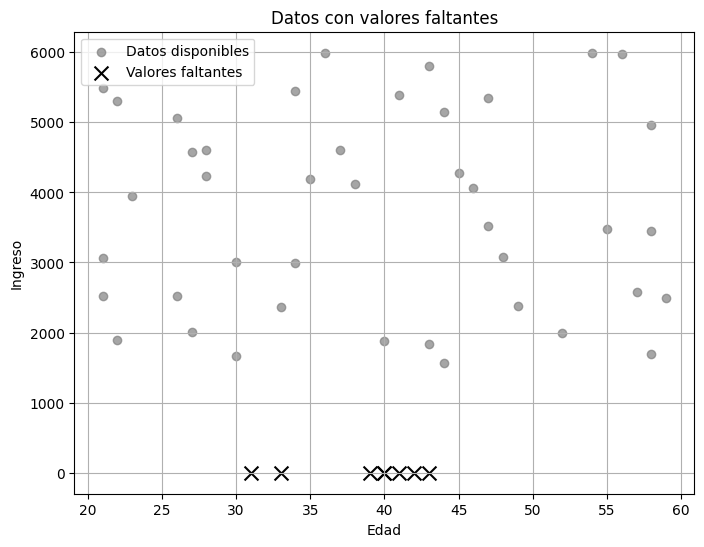

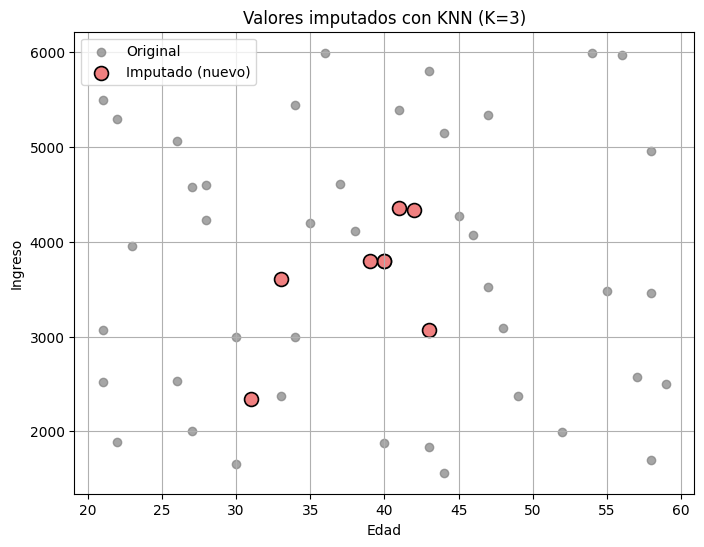

Valores faltantes antes de imputar:
Edad       0
Ingreso    8
dtype: int64

Valores faltantes después de imputar:
Edad       0
Ingreso    0
dtype: int64


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

#  Dataset
np.random.seed(42)
n_samples = 50
data = pd.DataFrame({
    "Edad": np.random.randint(20, 60, size=n_samples),
    "Ingreso": np.random.randint(1500, 6000, size=n_samples)
})

# valores faltantes 
data_missing = data.copy()
missing_indices = np.random.choice(data.index, size=8, replace=False)
data_missing.loc[missing_indices, "Ingreso"] = np.nan

# Imputación con KNN 
imputer = KNNImputer(n_neighbors=3)
data_imputed = pd.DataFrame(imputer.fit_transform(data_missing),
                            columns=data.columns)

# -------- Máscara de valores imputados --------
mask_missing = data_missing["Ingreso"].isnull()

# figure
plt.figure(figsize=(8,6))
plt.scatter(data_missing["Edad"], data_missing["Ingreso"],
            color="gray", alpha=0.7, label="Datos disponibles")
plt.scatter(data_missing.loc[mask_missing, "Edad"],
            [0]*mask_missing.sum(), 
            marker="x", color="black", s=100, label="Valores faltantes")

plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.title("Datos con valores faltantes")
plt.legend()
plt.grid(True)
plt.show()

# figure
plt.figure(figsize=(8,6))
plt.scatter(data_imputed.loc[~mask_missing, "Edad"],
            data_imputed.loc[~mask_missing, "Ingreso"],
            color="gray", alpha=0.7, label="Original")
plt.scatter(data_imputed.loc[mask_missing, "Edad"],
            data_imputed.loc[mask_missing, "Ingreso"],
            color="lightcoral", edgecolors="black", linewidths=1.2,
            s=100, label="Imputado (nuevo)")

plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.title("Valores imputados con KNN (K=3)")
plt.legend()
plt.grid(True)
plt.show()

# -------- Verificación --------
print("Valores faltantes antes de imputar:")
print(data_missing.isnull().sum())

print("\nValores faltantes después de imputar:")
print(data_imputed.isnull().sum())


# <span style="color:#2F749F;"><strong>4. Imputación por Regresión</strong></span>

La **imputación por regresión** es un método que utiliza modelos estadísticos o de aprendizaje automático para **predecir los valores faltantes** de una variable a partir de otras variables disponibles. Este enfoque asume que existe una **relación lineal o no lineal** entre la variable con datos ausentes y las variables predictoras [(Little & Rubin, 2019)](https://doi.org/10.1002/9781119482260).

El procedimiento consiste en ajustar un **modelo de regresión** (por ejemplo, lineal, logística o basada en árboles) con las observaciones completas y luego **predecir los valores faltantes** utilizando las variables explicativas.  
De esta forma, los valores imputados conservan la coherencia estadística y la correlación con otras variables del conjunto de datos [(Allison, 2001)](https://doi.org/10.4135/9781412985079).

<p align="center">
    <img src="Local\imgs\U4\regresion.png" alt="imputacion-regresion" width="700" height="300">
</p>

Imagen adaptada de [feaz-book.com](https://feaz-book.com/missing-model).

> **El procedimiento general de imputación por regresión puede resumirse en los siguientes pasos:**
- **Paso 1:** Identificar la variable con valores faltantes y seleccionar las variables predictoras más relevantes.  
- **Paso 2:** Entrenar un modelo de regresión utilizando únicamente los registros completos.  
- **Paso 3:** Utilizar el modelo ajustado para estimar (predecir) los valores ausentes.  
- **Paso 4:** Sustituir los valores faltantes por las predicciones obtenidas.  



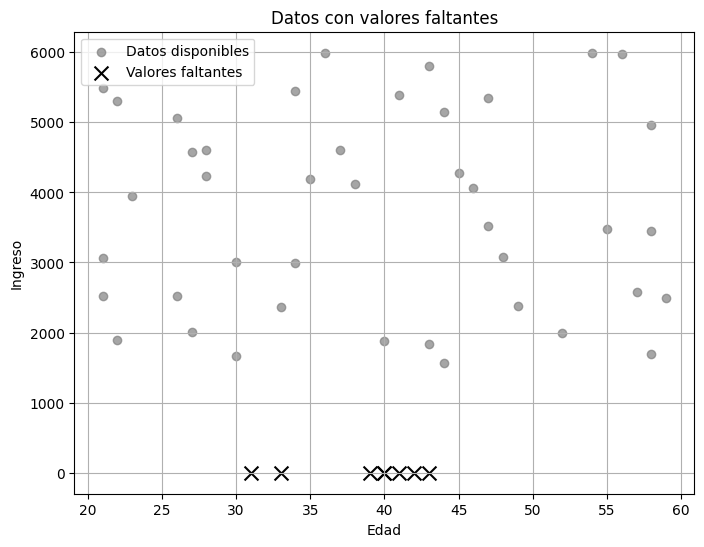

c:\Users\bernarda.salazar\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


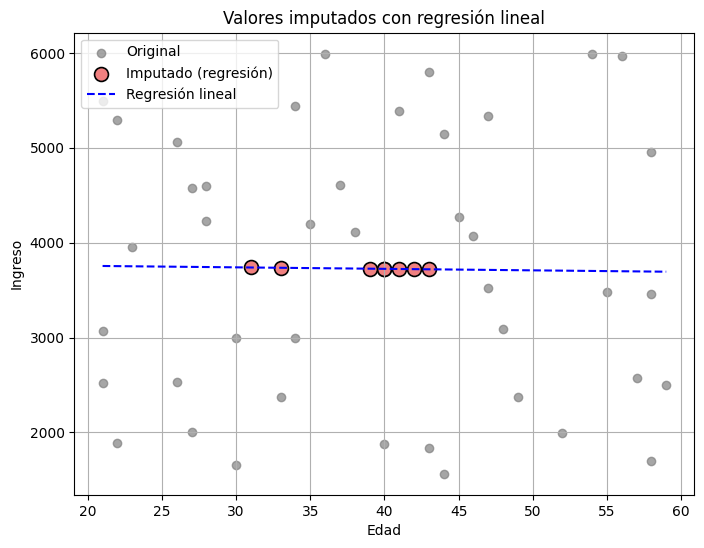

Valores faltantes antes de imputar:
Edad       0
Ingreso    8
dtype: int64

Valores faltantes después de imputar:
Edad       0
Ingreso    0
dtype: int64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Dataset 
np.random.seed(42)
n_samples = 50
data = pd.DataFrame({
    "Edad": np.random.randint(20, 60, size=n_samples),
    "Ingreso": np.random.randint(1500, 6000, size=n_samples)
})

# Introducir valores faltantes
data_missing = data.copy()
missing_indices = np.random.choice(data.index, size=8, replace=False)
data_missing.loc[missing_indices, "Ingreso"] = np.nan

# Separar datos completos y faltantes 
mask_missing = data_missing["Ingreso"].isnull()
X_train = data_missing.loc[~mask_missing, ["Edad"]]
y_train = data_missing.loc[~mask_missing, "Ingreso"]

X_missing = data_missing.loc[mask_missing, ["Edad"]]

# regresión lineal 
reg = LinearRegression()
reg.fit(X_train, y_train)

# valores faltantes 
data_imputed = data_missing.copy()
data_imputed.loc[mask_missing, "Ingreso"] = reg.predict(X_missing)

#plt.figure(figsize=(8,6))
plt.scatter(data_missing["Edad"], data_missing["Ingreso"],
            color="gray", alpha=0.7, label="Datos disponibles")
plt.scatter(data_missing.loc[mask_missing, "Edad"],
            [0]*mask_missing.sum(),
            marker="x", color="black", s=100, label="Valores faltantes")

plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.title("Datos con valores faltantes")
plt.legend()
plt.grid(True)
plt.show()

# 
plt.figure(figsize=(8,6))
plt.scatter(data_imputed.loc[~mask_missing, "Edad"],
            data_imputed.loc[~mask_missing, "Ingreso"],
            color="gray", alpha=0.7, label="Original")
plt.scatter(data_imputed.loc[mask_missing, "Edad"],
            data_imputed.loc[mask_missing, "Ingreso"],
            color="lightcoral", edgecolors="black", linewidths=1.2,
            s=100, label="Imputado (regresión)")
x_line = np.linspace(data["Edad"].min(), data["Edad"].max(), 100).reshape(-1,1)
y_line = reg.predict(x_line)
plt.plot(x_line, y_line, color="blue", linestyle="--", label="Regresión lineal")

plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.title("Valores imputados con regresión lineal")
plt.legend()
plt.grid(True)
plt.show()

# -------- Verificación --------
print("Valores faltantes antes de imputar:")
print(data_missing.isnull().sum())

print("\nValores faltantes después de imputar:")
print(data_imputed.isnull().sum())


# <span style="color:#2F749F;"><strong>5. Interpolación y métodos secuenciales (LOCF / NOCB)</strong></span>

La **interpolación** y los **métodos secuenciales** son técnicas empleadas para imputar valores faltantes en series temporales o datos ordenados secuencialmente. Su principio se basa en **estimar o propagar valores adyacentes** para mantener la continuidad y coherencia temporal del conjunto de datos [(Hyndman & Athanasopoulos, 2021)](https://otexts.com/fpp3/).

La **interpolación** calcula los valores ausentes mediante una **función matemática** que conecta los puntos conocidos. Los métodos más comunes son la **interpolación lineal**, **polinómica** o **spline**, donde se asume una transición suave entre los datos observados.  
Por otro lado, los **métodos secuenciales**, como **LOCF (Last Observation Carried Forward)** y **NOCB (Next Observation Carried Backward)**, imputan los valores faltantes propagando el último o el siguiente valor no ausente, respectivamente [(Schafer & Graham, 2002)](https://doi.org/10.1037/1082-989X.7.2.147).


> **El procedimiento general de interpolación o métodos secuenciales sigue los siguientes pasos:**
- **Paso 1:** Identificar la variable o serie temporal con valores faltantes.  
- **Paso 2:** Seleccionar el método apropiado según la naturaleza de los datos:
  - **Interpolación lineal:** se estima el valor faltante mediante la línea recta que conecta los puntos anterior y posterior.  
  - **Interpolación spline/polinómica:** se usa una función más flexible para capturar curvaturas.  
  - **LOCF:** se replica el último valor observado hacia adelante.  
  - **NOCB:** se replica el siguiente valor observado hacia atrás.  
- **Paso 3:** Verificar la coherencia de la serie imputada y la continuidad en las transiciones.  


> **Ejemplo:** En un registro de temperatura horaria donde se pierden datos por fallas en el sensor, la interpolación lineal puede estimar valores intermedios. Si el análisis busca conservar la tendencia local sin modificar la estructura, se pueden aplicar LOCF o NOCB según la dirección del tiempo.

## <span style="color:#2F749F;"><strong>Ventajas</strong></span>

- Fáciles de implementar y de **bajo costo computacional**.  
- Preservan la **coherencia temporal** y la **secuencia lógica** de los datos.  
- Adecuados para **series regulares** con pequeños vacíos o interrupciones.  
- Los métodos LOCF y NOCB no introducen valores fuera del rango observado.  

## <span style="color:#2F749F;"><strong>Limitaciones</strong></span>

- No capturan **cambios abruptos o no lineales** si se usa interpolación simple.  
- LOCF y NOCB pueden **distorsionar tendencias** al repetir valores sin variación.    
- Requieren precaución en contextos donde la **dependencia temporal** influye en el análisis posterior.  


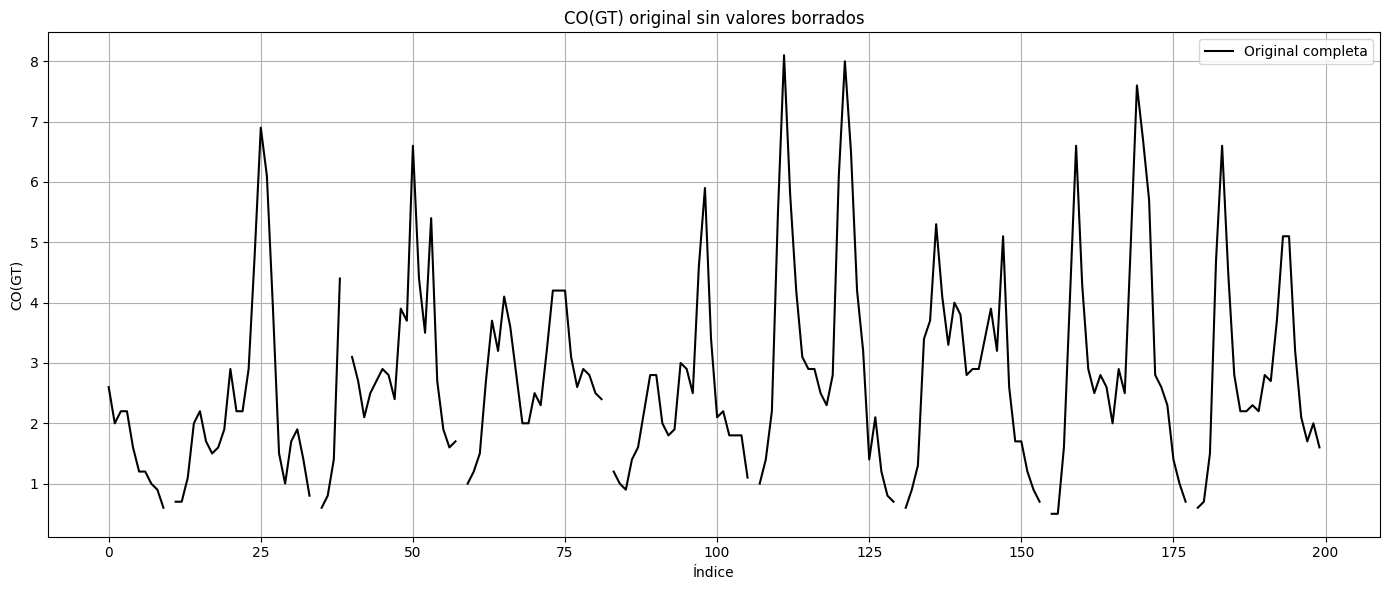

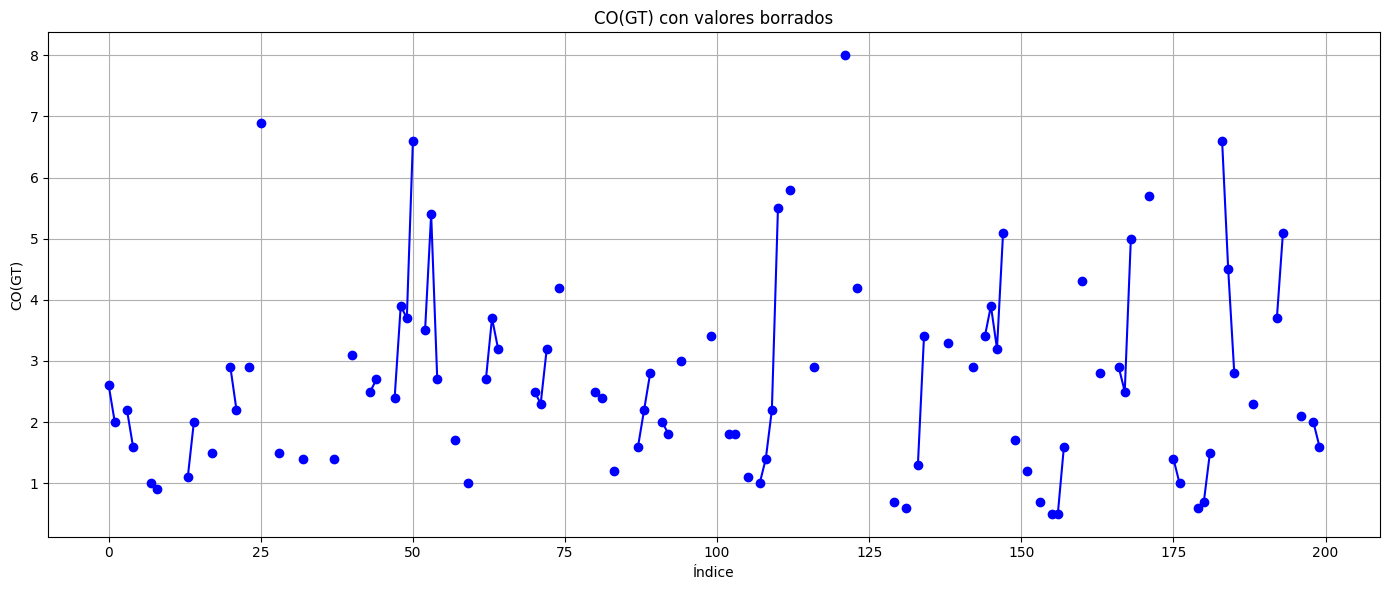

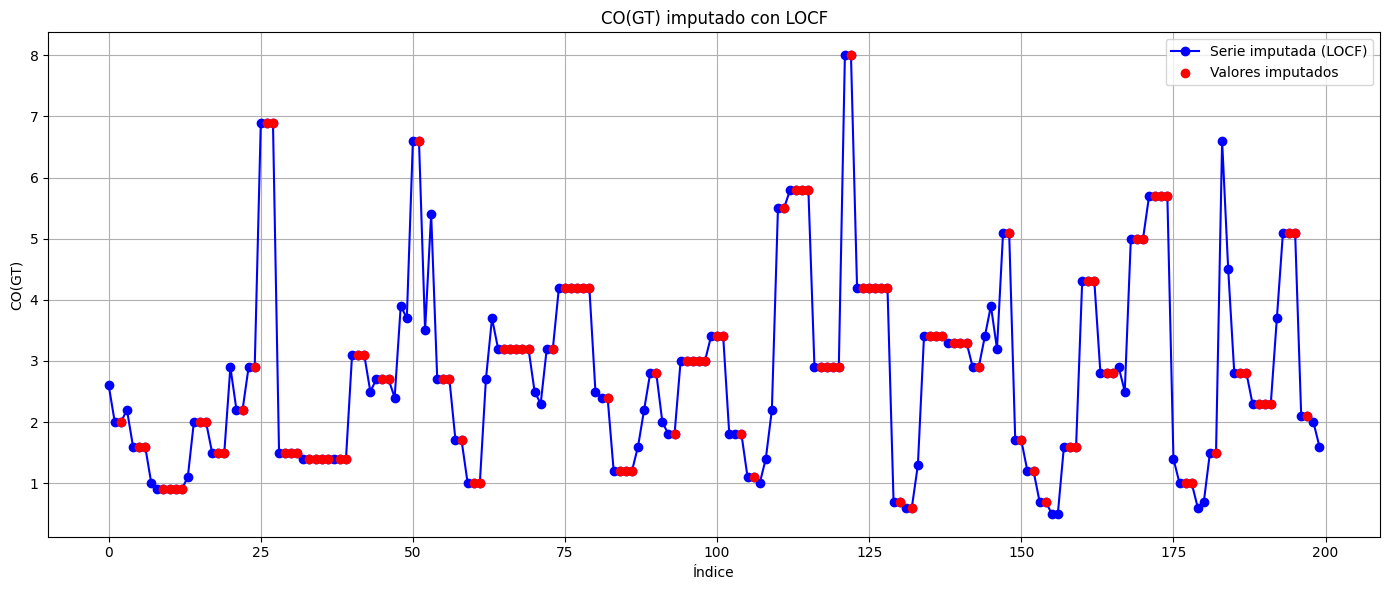

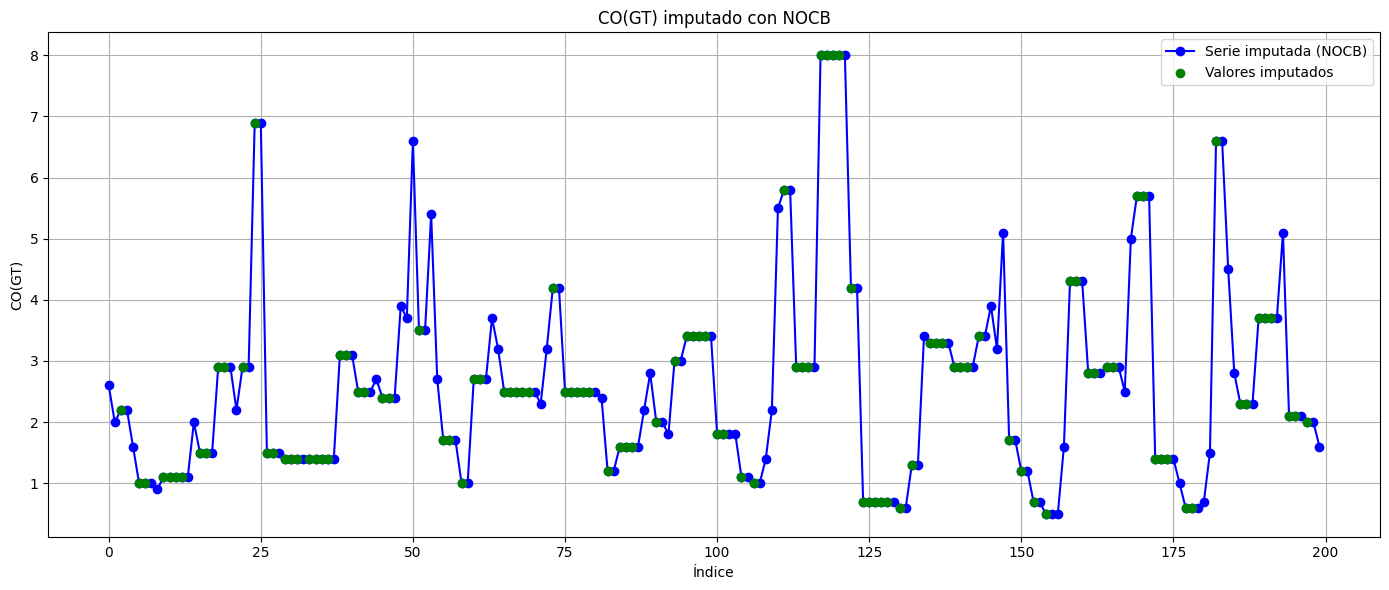

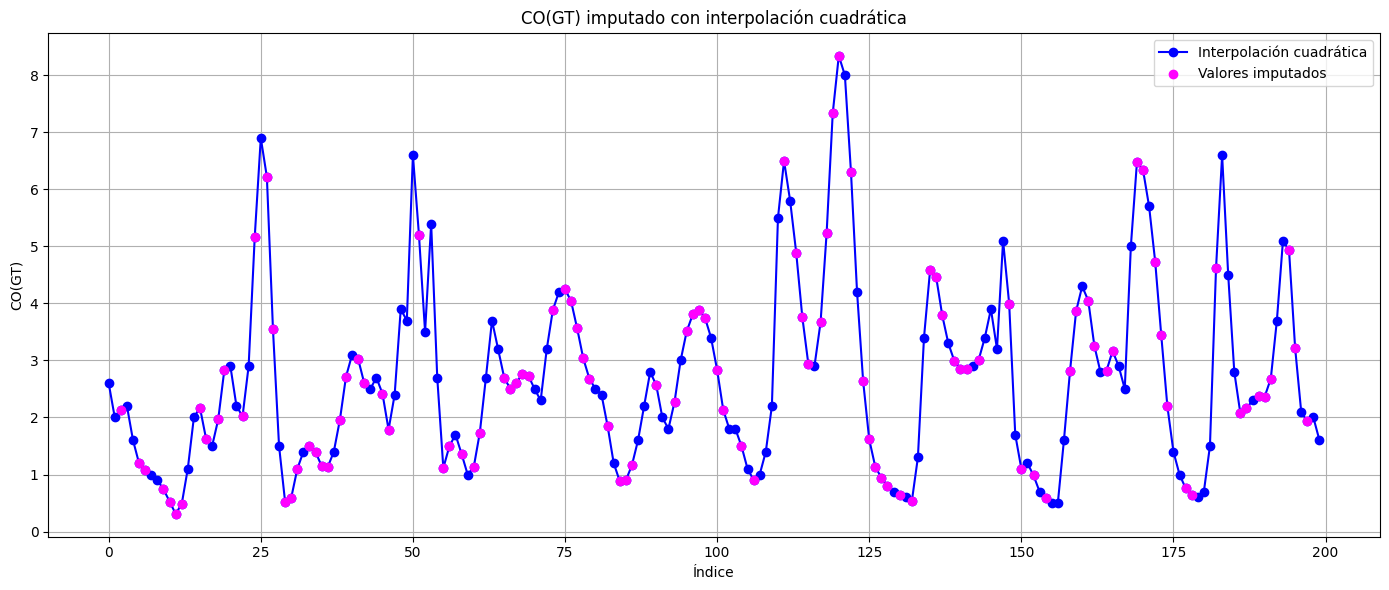

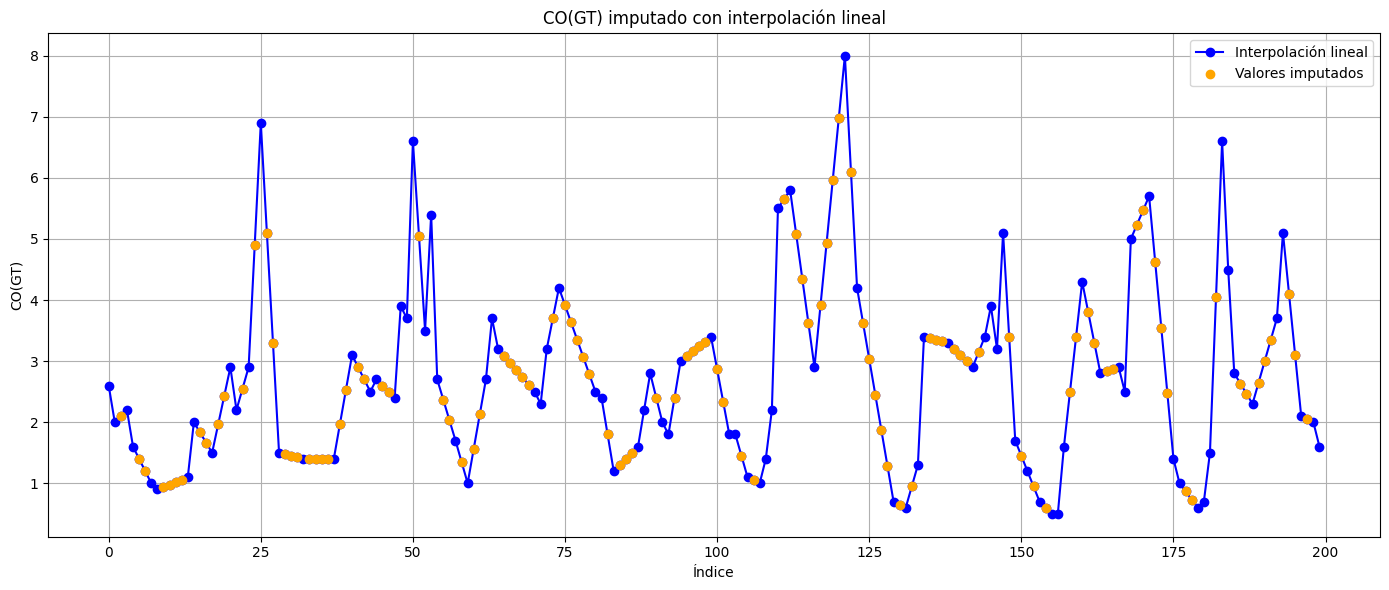

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset
file_path = r"data\AirQuality.csv"
df = pd.read_csv(file_path, sep=';', decimal=',', low_memory=False)

# Limpiar nombres de columnas
df.columns = [col.strip() for col in df.columns if col.strip() != '']

# Convertir la columna 'CO(GT)' a numérica y reemplazar -200 por NaN
df['CO(GT)'] = pd.to_numeric(df['CO(GT)'], errors='coerce')
df['CO(GT)'] = df['CO(GT)'].replace(-200, np.nan)

# Guardar copia original sin borrar
df_original = df.head(200).copy()

# Crear versión con valores borrados
df_200 = df_original.copy()
np.random.seed(42)
indices_a_borrar = np.random.choice(df_200.index, size=100, replace=False)
df_200.loc[indices_a_borrar, 'CO(GT)'] = np.nan

df_200['CO_Interpolado'] = df_200['CO(GT)'].interpolate(method='linear')

# figure
plt.figure(figsize=(14, 6))
plt.plot(df_original.index, df_original['CO(GT)'], color='black', label='Original completa')
plt.title('CO(GT) original sin valores borrados')
plt.xlabel('Índice')
plt.ylabel('CO(GT)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# figure
plt.figure(figsize=(14, 6))
plt.plot(df_200.index, df_200['CO(GT)'], marker='o', color='blue')
plt.title('CO(GT) con valores borrados')
plt.xlabel('Índice')
plt.ylabel('CO(GT)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Aplicar LOCF
df_200['CO_LOCF'] = df_200['CO(GT)'].ffill()
imputados = df_200['CO(GT)'].isna()

# figure
plt.figure(figsize=(14, 6))
plt.plot(df_200.index, df_200['CO_LOCF'], label='Serie imputada (LOCF)', color='blue', marker='o')
plt.scatter(df_200.index[imputados], df_200['CO_LOCF'][imputados], color='red', label='Valores imputados', zorder=5)
plt.title('CO(GT) imputado con LOCF')
plt.xlabel('Índice')
plt.ylabel('CO(GT)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Aplicar NOCB
df_200['CO_NOCB'] = df_200['CO(GT)'].bfill()
imputados_nocb = df_200['CO(GT)'].isna()

# figure
plt.figure(figsize=(14, 6))
plt.plot(df_200.index, df_200['CO_NOCB'], label='Serie imputada (NOCB)', color='blue', marker='o')
plt.scatter(df_200.index[imputados_nocb], df_200['CO_NOCB'][imputados_nocb], color='green', label='Valores imputados', zorder=5)
plt.title('CO(GT) imputado con NOCB')
plt.xlabel('Índice')
plt.ylabel('CO(GT)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Aplicar interpolación cuadrática
df_200['CO_Quadratic'] = df_200['CO(GT)'].interpolate(method='polynomial', order=2)
# Identificar los valores imputados
imputados_quad = df_200['CO(GT)'].isna()
# Graficar
plt.figure(figsize=(14, 6))
plt.plot(df_200.index, df_200['CO_Quadratic'], label='Interpolación cuadrática', color='blue', marker='o')
plt.scatter(df_200.index[imputados_quad], df_200['CO_Quadratic'][imputados_quad], color='fuchsia', label='Valores imputados', zorder=5)
plt.title('CO(GT) imputado con interpolación cuadrática')
plt.xlabel('Índice')
plt.ylabel('CO(GT)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Identificar los valores imputados por interpolación lineal
imputados_interp = df_200['CO(GT)'].isna()

plt.figure(figsize=(14, 6))
plt.plot(df_200.index, df_200['CO_Interpolado'], label='Interpolación lineal', color='blue', marker='o')
plt.scatter(df_200.index[imputados_interp], df_200['CO_Interpolado'][imputados_interp], color='orange', label='Valores imputados', zorder=5)
plt.title('CO(GT) imputado con interpolación lineal')
plt.xlabel('Índice')
plt.ylabel('CO(GT)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

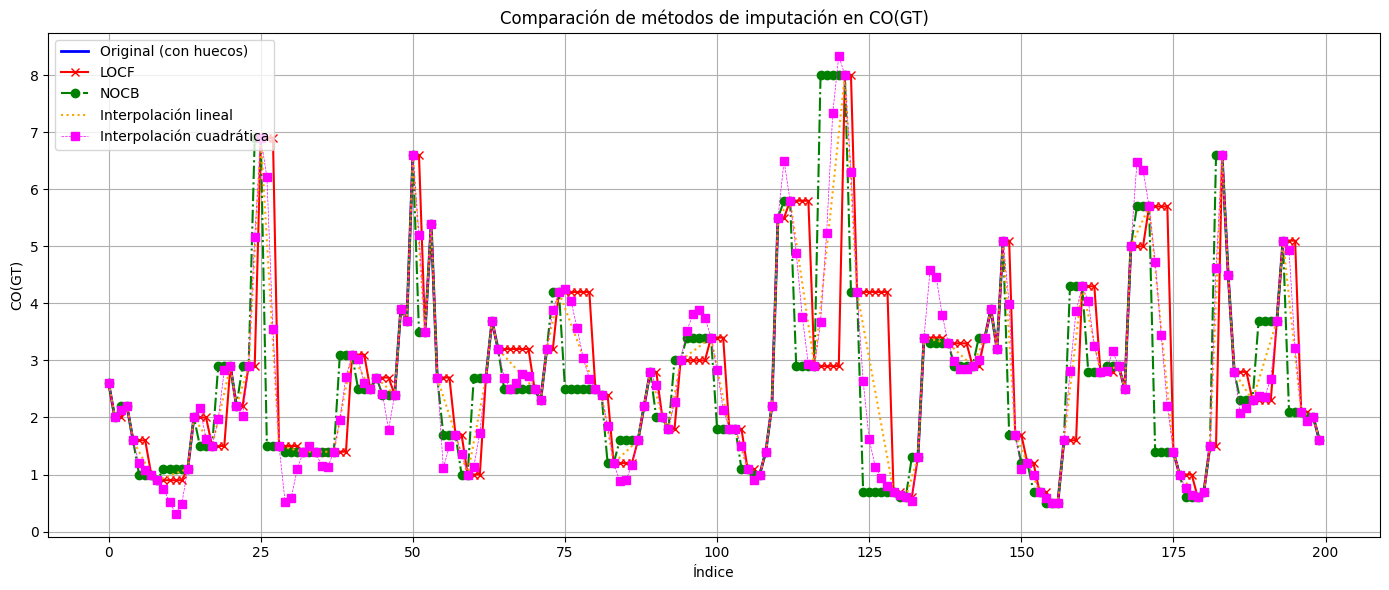

In [13]:
# Graficar
plt.figure(figsize=(14, 6))

# Señal original con huecos
plt.plot(df_200.index, df_200['CO(GT)'], label='Original (con huecos)', color='blue', linewidth=2)

# Líneas de imputación
plt.plot(df_200.index, df_200['CO_LOCF'], label='LOCF', color='red', marker='x')
plt.plot(df_200.index, df_200['CO_NOCB'], label='NOCB', color='green', linestyle='-.', marker='o')
plt.plot(df_200.index, df_200['CO_Interpolado'], label='Interpolación lineal', color='orange', linestyle=':')
plt.plot(df_200.index, df_200['CO_Quadratic'], label='Interpolación cuadrática', color='fuchsia', marker='s',linestyle='--',linewidth=0.5)

plt.title('Comparación de métodos de imputación en CO(GT)')
plt.xlabel('Índice')
plt.ylabel('CO(GT)')
plt.legend(loc='upper left')  
plt.grid(True)
plt.tight_layout()
plt.show()


# <span style="color:#2F749F;"><strong>6. Imputación por muestreo aleatorio</strong></span>

La **imputación por muestreo aleatorio** es una técnica simple pero efectiva para reemplazar valores faltantes mediante la **selección aleatoria de valores observados** en la misma variable. En lugar de usar medidas centrales como la media o la mediana, este método **preserva la variabilidad natural** de los datos al incorporar el componente aleatorio en la imputación [(Rubin, 1987)](https://doi.org/10.1002/9781119526292).

El procedimiento consiste en identificar los valores no faltantes de una variable y, para cada observación con datos ausentes, **muestrear aleatoriamente** uno de los valores existentes. De esta forma, los valores imputados mantienen una distribución similar a la original y no distorsionan las relaciones estadísticas del conjunto de datos.


> **El procedimiento general de imputación por muestreo aleatorio puede resumirse así:**
- **Paso 1:** Identificar la variable con valores faltantes.  
- **Paso 2:** Extraer los valores observados disponibles en dicha variable.  
- **Paso 3:** Para cada valor faltante, seleccionar aleatoriamente un valor del conjunto observado.  
- **Paso 4:** Sustituir los valores ausentes por los seleccionados.  

> **Ejemplo:** Si en una base de datos de estudiantes existen valores faltantes en la variable “edad”, se puede imputar cada valor ausente tomando aleatoriamente una edad de entre las registradas.



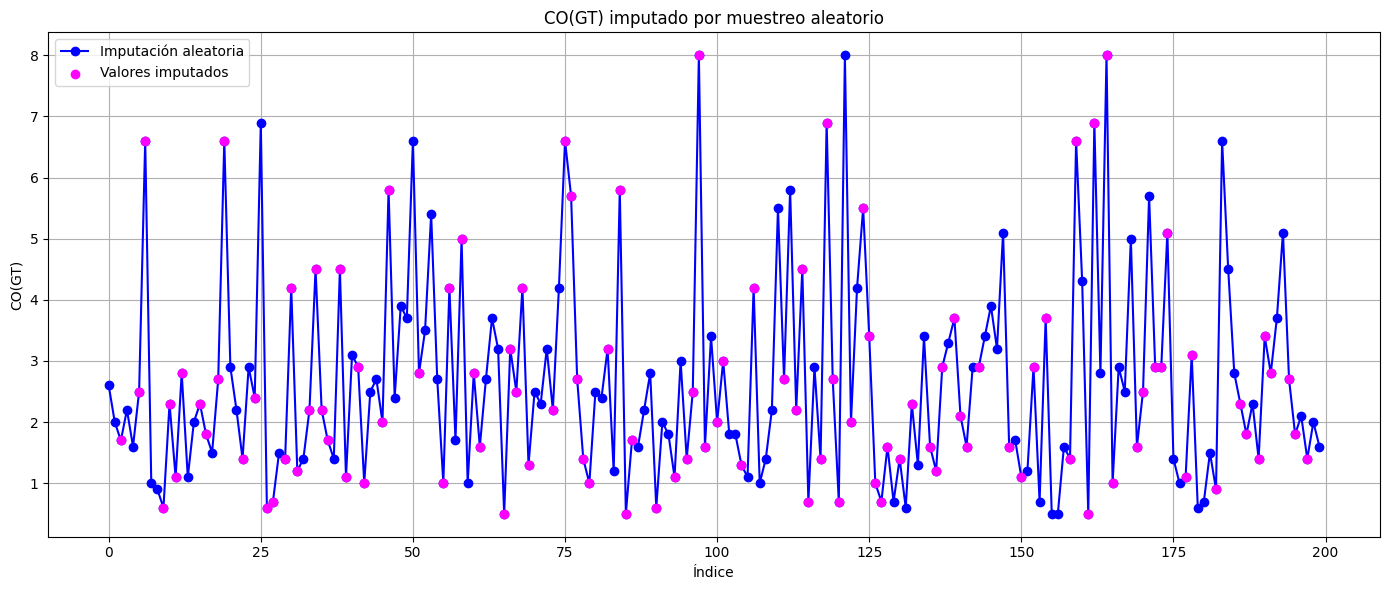

In [14]:
# Imputación por muestreo aleatorio
valores_validos = df_200['CO(GT)'].dropna().values
np.random.seed(123)  # Para reproducibilidad
valores_imputados = np.random.choice(valores_validos, size=df_200['CO(GT)'].isna().sum(), replace=True)

# Crear nueva columna con imputación
df_200['CO_Random'] = df_200['CO(GT)'].copy()
df_200.loc[df_200['CO(GT)'].isna(), 'CO_Random'] = valores_imputados

# Identificar los valores imputados
imputados_random = df_200['CO(GT)'].isna()

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(df_200.index, df_200['CO_Random'], label='Imputación aleatoria', color='blue', marker='o')
plt.scatter(df_200.index[imputados_random], df_200['CO_Random'][imputados_random], color='magenta', label='Valores imputados', zorder=5)
plt.title('CO(GT) imputado por muestreo aleatorio')
plt.xlabel('Índice')
plt.ylabel('CO(GT)')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


> El **MAE (Mean Absolute Error)** mide el promedio de los errores absolutos entre los valores reales y los valores imputados o predichos. Es decir, calcula cuánto se equivocó en promedio el método al rellenar los datos faltantes.

**Interpretación:**
- MAE = 0 → imputación perfecta (todos los valores imputados son iguales a los reales).
- MAE bajo → buena aproximación.
- MAE alto → el método se equivocó más al imputar.

MAE LOCF: 1.0999999999999999
MAE NOCB: 1.0050505050505052
MAE Interpolación lineal: 0.7
MAE Interpolación cuadrática: 0.6393722303470505
MAE Muestreo aleatorio: 1.7424242424242424


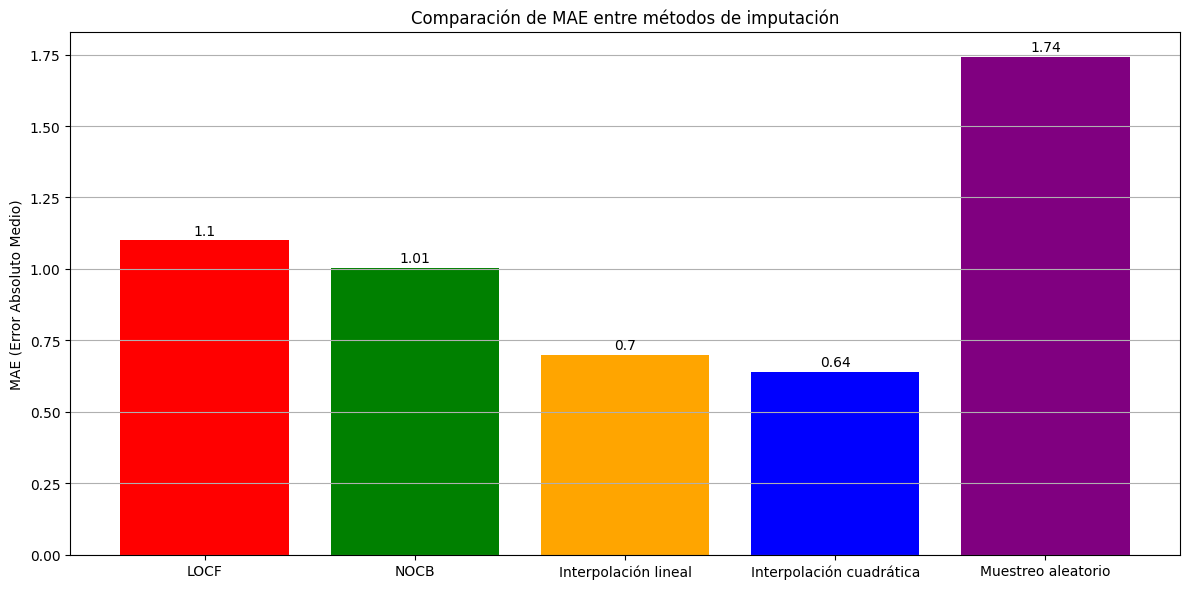

In [ ]:
# Calcular errores 
original = df_original['CO(GT)'].copy()

errores_locf = np.abs(original[indices_a_borrar] - df_200['CO_LOCF'][indices_a_borrar])
errores_nocb = np.abs(original[indices_a_borrar] - df_200['CO_NOCB'][indices_a_borrar])
errores_interp = np.abs(original[indices_a_borrar] - df_200['CO_Interpolado'][indices_a_borrar])
errores_quad = np.abs(original[indices_a_borrar] - df_200['CO_Quadratic'][indices_a_borrar])
errores_random = np.abs(original[indices_a_borrar] - df_200['CO_Random'][indices_a_borrar])

# Calcular MAE
mae_locf = errores_locf.mean()
mae_nocb = errores_nocb.mean()
mae_interp = errores_interp.mean()
mae_quad = errores_quad.mean()
mae_random = errores_random.mean()

# resultados
print("MAE LOCF:", mae_locf)
print("MAE NOCB:", mae_nocb)
print("MAE Interpolación lineal:", mae_interp)
print("MAE Interpolación cuadrática:", mae_quad)
print("MAE Muestreo aleatorio:", mae_random)

# figure
metodos = ['LOCF', 'NOCB', 'Interpolación lineal', 'Interpolación cuadrática', 'Muestreo aleatorio']
mae_valores = [mae_locf, mae_nocb, mae_interp, mae_quad, mae_random]

plt.figure(figsize=(12, 6))
bars = plt.bar(metodos, mae_valores, color=['red', 'green', 'orange', 'blue', 'purple'])
plt.title('Comparación de MAE entre métodos de imputación')
plt.ylabel('MAE (Error Absoluto Medio)')
plt.grid(axis='y')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()


# <span style="color:#2F749F;"><strong>Referencias</strong></span>

Little, R. J. A., & Rubin, D. B. (2019). [*Statistical analysis with missing data*](https://onlinelibrary.wiley.com/doi/book/10.1002/9781119482260). John Wiley & Sons.  

Van Buuren, S. (2018). [*Flexible imputation of missing data*](https://stefvanbuuren.name/fimd/). CRC Press.  

Zhang, S. (2011). [*Shell-neighbor method and its application in missing data imputation*](https://link.springer.com/article/10.1007/s10489-009-0207-6#:~:text=The%20SNI%20fills%20in%20an,neighbors%20of%20the%20incomplete%20instance.). *Knowledge-Based Systems, 24*(5), 709–715.  
